RMSE between fitted sample path and original optimal points: 0.5357
RMSE between the two fitted curves: 0.0774


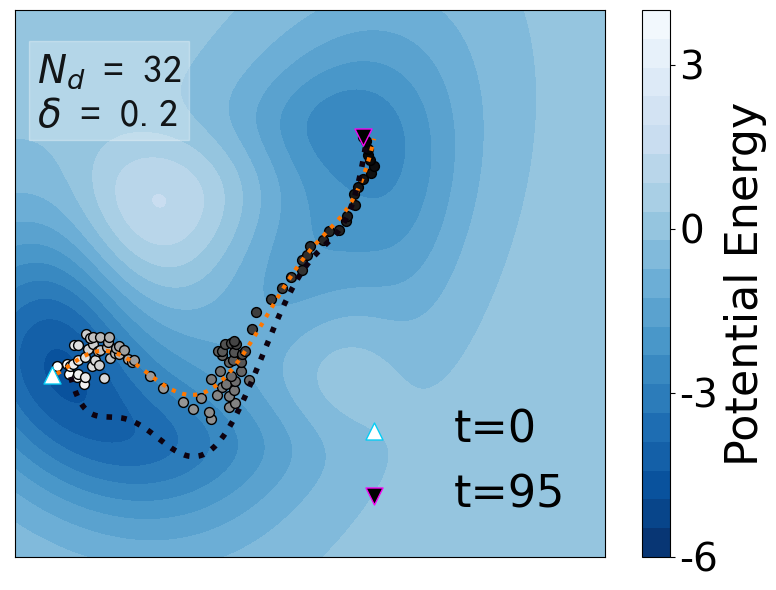

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import os
import pandas as pd
from scipy.interpolate import make_interp_spline

def potential_energy(x, y):
    """计算势能面"""
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0

    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5

    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5

    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * np.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)

    return well1 + well2 + barrier

def plot_sampled_path(Nstep, d, N):
    # 创建网格
    x_grid = np.linspace(0, 8, 500)
    y_grid = np.linspace(0, 6, 500)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = potential_energy(X, Y)

    # 读取数据
    path_data = pd.read_csv(f'results/path_sampled_{d}_{N}d.txt', sep='\t')
    x_coords = path_data['x'].values[:Nstep]
    y_coords = path_data['y'].values[:Nstep]

    optimal_path = pd.read_csv('optmal_path_ref.txt', sep=r'\s+')
    opt_x = optimal_path['X'].values
    opt_y = optimal_path['Y'].values

    fig, ax = plt.subplots(figsize=(8, 6))

    # 绘制势能面
    levels = np.linspace(-6, 4, 20)
    contour = ax.contourf(
        X, Y, Z,
        levels=levels,
        cmap="Blues_r",
        alpha=1,
        vmin=-6, vmax=4
    )
    
    # contour = ax.pcolormesh(X, Y, Z, cmap="Blues_r", alpha=0.9, vmin=-4, vmax=3, shading='auto')
    cbar = fig.colorbar(contour, ax=ax, pad=0.05)
    cbar.set_label('Potential Energy', fontsize=32)
    cbar.ax.tick_params(labelsize=28)
    cbar.set_ticks([-6, -3, 0, 3])
    cbar.set_ticklabels(['-6','-3', '0', '3'])

    # 对采样点和最优路径进行多项式拟合
    degree = 6
    p_sample = np.polyfit(x_coords, y_coords, deg=degree)
    p_optimal = np.polyfit(opt_x, opt_y, deg=degree)

    # 计算并打印RMSE误差
    rmse_sample_vs_optimal = np.sqrt(np.mean((np.polyval(p_sample, opt_x) - opt_y) ** 2))
    print(f"RMSE between fitted sample path and original optimal points: {rmse_sample_vs_optimal:.4f}")

    # 拟合后的曲线绘制
    t_smooth = np.linspace(0, 1, 500)
    x_fit = np.linspace(min(x_coords), max(x_coords), 500)
    y_fit_sample = np.polyval(p_sample, x_fit)
    ax.plot(x_fit, y_fit_sample, color="#FF7700", linestyle=':', linewidth=3)

    x_fit_optimal = np.linspace(min(opt_x), max(opt_x), 500)
    y_fit_optimal = np.polyval(p_optimal, x_fit_optimal)
    ax.plot(x_fit_optimal, y_fit_optimal, color="#0E020F", linestyle=':', linewidth=4)

    # RMSE between the two fitted curves
    rmse_fitted_curves = np.sqrt(np.mean((y_fit_sample - np.polyval(p_sample, x_fit_optimal)) ** 2))
    print(f"RMSE between the two fitted curves: {rmse_fitted_curves:.4f}")

    # 绘制采样散点（白 → 黑 渐变）
    cmap_bw = colors.LinearSegmentedColormap.from_list("white_to_black", ["white", "black"])
    norm = plt.Normalize(vmin=1, vmax=Nstep)
    for i in range(Nstep):
        ax.scatter(x_coords[i], y_coords[i],
                   color=cmap_bw(norm(i+1)), s=50, alpha=1, edgecolors="black")

    # 坐标轴与图例
    ax.scatter(0.5, 2, c="white", s=150, marker='^', label='t=0', edgecolors="#08CDF4")
    ax.scatter(x_coords[-1], y_coords[-1], c="black", s=150, marker='v', label=f't={Nstep}', edgecolors="#F408F0")
    
    ax.text(
        0.3, 5.1, f"$N_d$ = {N}\n$δ$ = {d/10}",
        fontsize=28,                     # 字体大小
        fontweight='bold',               # 字体粗细
        fontfamily='SimHei',             # 字体（支持中文）
        color='black',                   # 颜色
        alpha=0.9,                       # 透明度
        # rotation=45,                     # 旋转角度
        ha='left',                     # 水平对齐：left, center, right
        va='center',                     # 垂直对齐：top, center, bottom, baseline
        bbox=dict(                       # 文本框样式
            boxstyle='square',            # 方框样式：round, square, circle
            facecolor='white',          # 填充色
            edgecolor='white',             # 边框颜色
            alpha=0.3,                   # 透明度
            pad=0.2                      # 内边距
        )
    )
    
    # ax.set_xlabel('X (Ns = 32)', fontsize=28)
    ax.set_xlabel('', fontsize=28)
    # ax.set_xticks([2,4,6,8])
    ax.set_xticks([])
    # ax.set_ylabel('Y (Stepsize = 0.4)', fontsize=28)
    ax.set_ylabel('', fontsize=28)
    # ax.set_yticks([0,2,4,6])
    ax.set_yticks([])
    ax.legend(fontsize=32, loc='lower right', framealpha=0)
    # ax.tick_params(axis='both', which='major', labelsize=24)

    plt.tight_layout()
    plt.savefig(f'figures/2d_path_sampled_{d}_{N}d.tiff', format='tiff', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    dstep = 2   # 步长×10
    dir_N = 32  # 方向数
    Nstep = 95
    plot_sampled_path(Nstep, dstep, dir_N)

## 分析采样效率 -- > Nstep取倒数后归一化
## 分析采样准确度 -- > RMSEc 不归一化

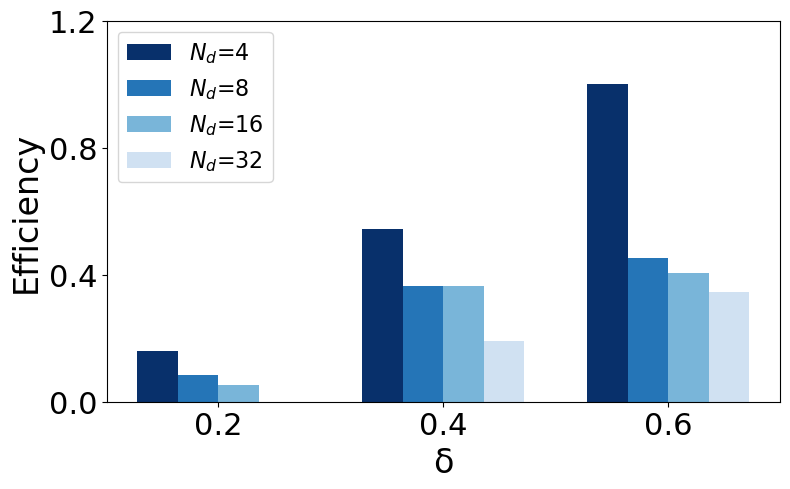

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 确保 figures 目录存在
os.makedirs('figures', exist_ok=True)

# 读取数据，允许空白分隔，并跳过开头空格
data = pd.read_csv('rmse_sample_1.txt', sep=r'\s+', header=None, 
                   names=['Length', 'Nd', 'Nstep', 'RMSEp', 'RMSEc'],
                   skipinitialspace=True, comment='#')

# 强制转换为数值类型，无法转换的变为 NaN
cols_to_convert = ['Length', 'Nd', 'Nstep']
for col in cols_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 删除包含 NaN 的行
data = data.dropna(subset=cols_to_convert)

# 转换为整数
data[cols_to_convert] = data[cols_to_convert].astype(int)

# 注意：你这次用了 Length = [2, 4, 6] → 对应标签 0.2, 0.4, 0.6
valid_lengths = [2, 4, 6]
data = data[data['Length'].isin(valid_lengths)]

# Step 1: 计算原始 Efficiency = 1 / Nstep
data['Efficiency_raw'] = 1.0 / data['Nstep']

# Step 2: 全局 Min-Max 归一化到 [0, 1]
eff_min = data['Efficiency_raw'].min()
eff_max = data['Efficiency_raw'].max()
if eff_max == eff_min:
    # 防止除零（所有值相同）
    data['Efficiency'] = 0.5
else:
    data['Efficiency'] = (data['Efficiency_raw'] - eff_min) / (eff_max - eff_min)

# 排序以便绘图
data = data.sort_values(['Length', 'Nd'])

# 定义红色渐变色：Nd=4 最浅，Nd=32 最深
red_colors = plt.cm.Blues(np.linspace(1, 0.2, 4))
# red_colors = ["#00354F", "#043AB0", "#fb6a4a", "#cb181d"]

# Nd 顺序固定为 [4, 8, 16, 32]
nd_order = [4, 8, 16, 32]
length_labels = ['0.2', '0.4', '0.6']
length_values = [2, 4, 6]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.18
n_groups = len(length_values)
index = np.arange(n_groups)

for i, nd in enumerate(nd_order):
    efficiencies = []
    for length in length_values:
        row = data[(data['Length'] == length) & (data['Nd'] == nd)]
        if not row.empty:
            eff = row['Efficiency'].iloc[0]
        else:
            eff = 0  # 缺失数据用 0 表示（柱子不显示或很矮）
        efficiencies.append(eff)
    
    ax.bar(index + i * bar_width, efficiencies, bar_width,
           color=red_colors[i], label=f'$N_d$={nd}')  # 修改这里，使'd'成为下标

# 设置横坐标
ax.set_xticks(index + bar_width * (len(nd_order) - 1) / 2)
ax.set_xticklabels(length_labels)

# 设置标签和标题
ax.set_xlabel('δ', fontsize=24)
ax.set_ylabel('Efficiency', fontsize=24)  # 修改纵轴标签
ax.set_yticks([0, 0.4, 0.8, 1.2])
ax.tick_params(axis='both', which='major', labelsize=22)

# 图例
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=16, title_fontsize=12, loc='upper left')

# 保存图像
plt.tight_layout()
plt.savefig('figures/efficiency.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

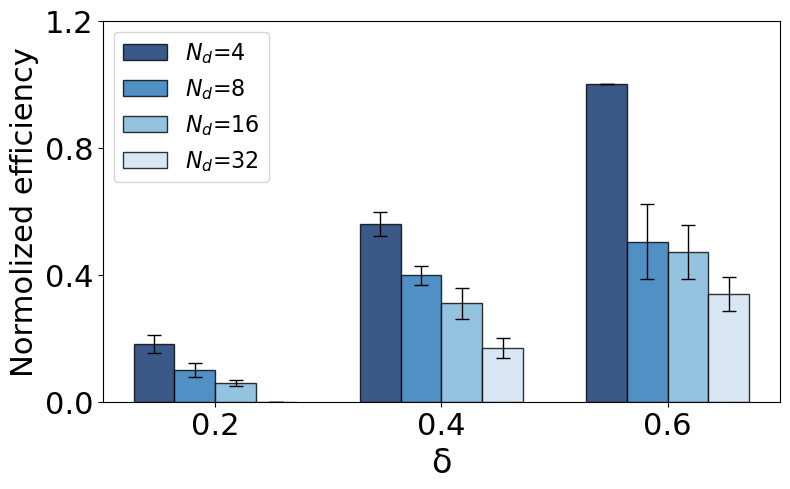

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import defaultdict

# 确保 figures 目录存在
os.makedirs('figures', exist_ok=True)

# 读取三个数据文件
file_names = ['rmse_sample_1.txt', 'rmse_sample_2.txt', 'rmse_sample_3.txt']
all_data = []

for file_name in file_names:
    # 读取数据，允许空白分隔，并跳过开头空格
    data = pd.read_csv(file_name, sep=r'\s+', header=None, 
                       names=['Length', 'Nd', 'Nstep', 'RMSEp', 'RMSEc'],
                       skipinitialspace=True, comment='#')
    
    # 强制转换为数值类型，无法转换的变为 NaN
    cols_to_convert = ['Length', 'Nd', 'Nstep']
    for col in cols_to_convert:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # 删除包含 NaN 的行
    data = data.dropna(subset=cols_to_convert)
    
    # 转换为整数
    data[cols_to_convert] = data[cols_to_convert].astype(int)
    
    # 只保留指定的 Length 值
    valid_lengths = [2, 4, 6]
    data = data[data['Length'].isin(valid_lengths)]
    
    # Step 1: 计算原始 Efficiency = 1 / Nstep
    data['Efficiency_raw'] = 1.0 / data['Nstep']
    
    # Step 2: 全局 Min-Max 归一化到 [0, 1]
    eff_min = data['Efficiency_raw'].min()
    eff_max = data['Efficiency_raw'].max()
    if eff_max == eff_min:
        # 防止除零（所有值相同）
        data['Efficiency'] = 0.5
    else:
        data['Efficiency'] = (data['Efficiency_raw'] - eff_min) / (eff_max - eff_min)
    
    # 排序以便后续处理
    data = data.sort_values(['Length', 'Nd'])
    all_data.append(data)

# 存储每个组合的 Efficiency 值
eff_dict = defaultdict(list)

# 收集所有文件中相同 (Length, Nd) 组合的 Efficiency 值
for data in all_data:
    for length in [2, 4, 6]:
        for nd in [4, 8, 16, 32]:
            row = data[(data['Length'] == length) & (data['Nd'] == nd)]
            if not row.empty:
                eff_value = row['Efficiency'].iloc[0]
                eff_dict[(length, nd)].append(eff_value)

# 计算每个组合的均值和标准偏差
mean_eff = {}
std_eff = {}

for key, values in eff_dict.items():
    if values:  # 确保有数据
        mean_eff[key] = np.mean(values)
        std_eff[key] = np.std(values, ddof=1)  # 使用样本标准偏差

# 定义红色渐变色：Nd=4 最浅，Nd=32 最深
red_colors = plt.cm.Blues(np.linspace(1, 0.2, 4))
# red_colors = ["#00354F", "#043AB0", "#fb6a4a", "#cb181d"]

# Nd 顺序固定为 [4, 8, 16, 32]
nd_order = [4, 8, 16, 32]
length_labels = ['0.2', '0.4', '0.6']
length_values = [2, 4, 6]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.18
n_groups = len(length_values)
index = np.arange(n_groups)

for i, nd in enumerate(nd_order):
    efficiencies = []
    error_bars = []
    
    for length in length_values:
        key = (length, nd)
        if key in mean_eff:
            efficiencies.append(mean_eff[key])
            error_bars.append(std_eff[key])
        else:
            efficiencies.append(0)  # 缺失数据用 0 表示
            error_bars.append(0)    # 无误差棒
    
    # 绘制柱状图，添加误差棒
    ax.bar(index + i * bar_width, efficiencies, bar_width,color=red_colors[i], label=f'$N_d$={nd}',yerr=error_bars, capsize=5, 
           error_kw={'elinewidth': 1, 'capthick': 1}, alpha = 0.8, edgecolor = "black")

# 设置横坐标
ax.set_xticks(index + bar_width * (len(nd_order) - 1) / 2)
ax.set_xticklabels(length_labels)

# 设置标签和标题
ax.set_xlabel('δ', fontsize=24)
ax.set_ylabel('Normolized efficiency', fontsize=22)
ax.set_yticks([0, 0.4, 0.8, 1.2])
ax.tick_params(axis='both', which='major', labelsize=22)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=16, title_fontsize=12, loc='upper left')
os.makedirs("figures",exist_ok=True)
plt.tight_layout()
plt.savefig('figures/efficiency-errorbar.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

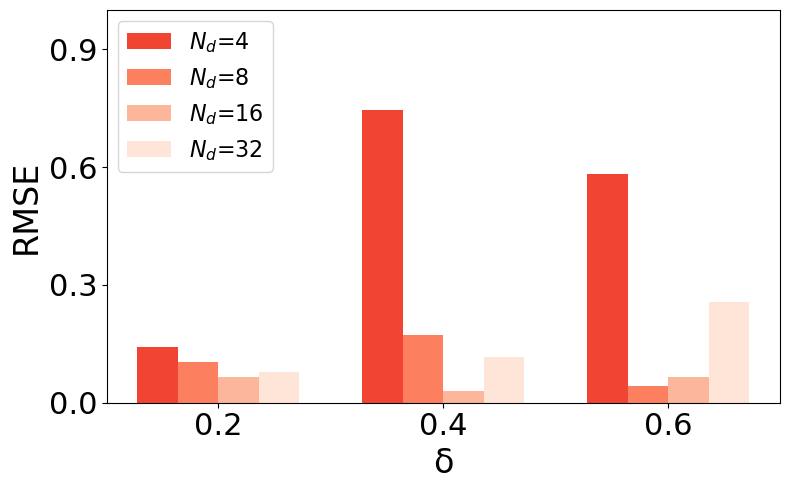

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.DataFrame({
    'Length': [2, 2, 2, 2, 4, 4, 4, 4, 6, 6, 6, 6],
    'Nd': [4, 8, 16, 32, 4, 8, 16, 32, 4, 8, 16, 32],
    'RMSEc': [0.1418, 0.1033, 0.0649, 0.0774, 0.2609, 0.1203, 0.0295, 0.1168, 0.5812, 0.0414, 0.0651, 0.2566]
})

# 确保 figures 目录存在
import os
os.makedirs('figures', exist_ok=True)

# 定义红色渐变色：Nd=4 最浅，Nd=32 最深
red_colors = plt.cm.Reds(np.linspace(0.6, 0.1, 4))

# Nd 顺序固定为 [4, 8, 16, 32]
nd_order = [4, 8, 16, 32]
length_labels = ['0.2', '0.4', '0.6']
length_values = [2, 4, 6]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.18
n_groups = len(length_values)
index = np.arange(n_groups)

for i, nd in enumerate(nd_order):
    rmsec_values = []
    for length in length_values:
        row = data[(data['Length'] == length) & (data['Nd'] == nd)]
        if not row.empty:
            rmsec = row['RMSEc'].iloc[0]
        else:
            rmsec = 0  # 缺失数据用 0 表示（柱子不显示或很矮）
        rmsec_values.append(rmsec)
    
    ax.bar(index + i * bar_width, rmsec_values, bar_width,
           color=red_colors[i], label=f'$N_d$={nd}')  # 修改这里，使'd'成为下标

# 设置横坐标
ax.set_xticks(index + bar_width * (len(nd_order) - 1) / 2)
ax.set_xticklabels(length_labels)

# 设置标签和标题
ax.set_xlabel('δ', fontsize=24)
ax.set_ylabel('RMSE', fontsize=24)  # 修改纵轴标签为 RMSEc
ax.tick_params(axis='both', which='major', labelsize=22)

# 动态设置Y轴范围，基于数据的最大值和最小值
ymin = data['RMSEc'].min() - 0.01
ymax = data['RMSEc'].max() + 0.01
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.3, 0.6, 0.9])  # 自动生成合理的刻度

# 图例
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=16, title_fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig('figures/rmsec-errorbar.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

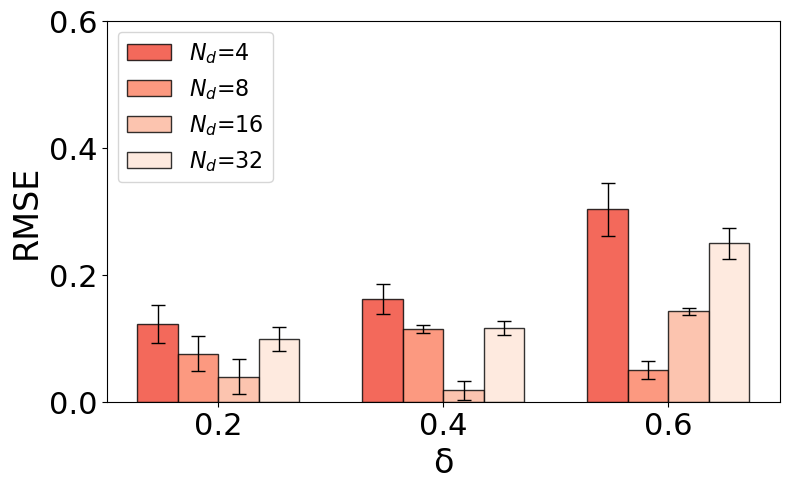

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.DataFrame({
    'Length': [2, 2, 2, 2, 4, 4, 4, 4, 6, 6, 6, 6],
    'Nd': [4, 8, 16, 32, 4, 8, 16, 32, 4, 8, 16, 32],
    'RMSEc1': [0.1418, 0.1033, 0.0649, 0.0774, 0.1654, 0.1203, 0.0295, 0.1168, 0.3394, 0.0414, 0.1366, 0.2566],
    'RMSEc2': [0.1367, 0.0489, 0.0101, 0.1140, 0.1824, 0.1072, 0.001, 0.1056, 0.2577, 0.0669, 0.1467, 0.2217],
    'RMSEc3': [0.0878, 0.0747, 0.0435, 0.1043, 0.1364, 0.1159, 0.0227, 0.1278, 0.3109, 0.0422, 0.1431, 0.2695]
})

# 计算每个(Length, Nd)组合的均值和标准偏差
# 创建一个字典来存储每个组合的数据
from collections import defaultdict
rmse_combinations = defaultdict(list)

# 将三个样本的数据收集到字典中
for idx, row in data.iterrows():
    length = row['Length']
    nd = row['Nd']
    key = (length, nd)
    
    # 添加三个RMSEc值
    rmse_combinations[key].append(row['RMSEc1'])
    rmse_combinations[key].append(row['RMSEc2'])
    rmse_combinations[key].append(row['RMSEc3'])

# 计算均值和标准偏差
mean_rmsec = {}
std_rmsec = {}

for key, values in rmse_combinations.items():
    mean_rmsec[key] = np.mean(values)
    std_rmsec[key] = np.std(values, ddof=1)  # 使用样本标准偏差

# 确保 figures 目录存在
import os
os.makedirs('figures', exist_ok=True)

# 定义红色渐变色：Nd=4 最浅，Nd=32 最深
red_colors = plt.cm.Reds(np.linspace(0.6, 0.1, 4))

# Nd 顺序固定为 [4, 8, 16, 32]
nd_order = [4, 8, 16, 32]
length_labels = ['0.2', '0.4', '0.6']
length_values = [2, 4, 6]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.18
n_groups = len(length_values)
index = np.arange(n_groups)

for i, nd in enumerate(nd_order):
    rmsec_means = []
    rmsec_stds = []
    
    for length in length_values:
        key = (length, nd)
        if key in mean_rmsec:
            rmsec_means.append(mean_rmsec[key])
            rmsec_stds.append(std_rmsec[key])
        else:
            rmsec_means.append(0)  # 缺失数据用 0 表示
            rmsec_stds.append(0)    # 无误差棒
    
    # 绘制柱状图，添加误差棒
    ax.bar(index + i * bar_width, rmsec_means, bar_width,color=red_colors[i], label=f'$N_d$={nd}',yerr=rmsec_stds, capsize=5, 
           error_kw={'elinewidth': 1, 'capthick': 1}, alpha = 0.8, edgecolor = "black")

# 设置横坐标
ax.set_xticks(index + bar_width * (len(nd_order) - 1) / 2)
ax.set_xticklabels(length_labels)

# 设置标签和标题
ax.set_xlabel('δ', fontsize=24)
ax.set_ylabel('RMSE', fontsize=24)  # 修改纵轴标签为 RMSE
ax.tick_params(axis='both', which='major', labelsize=22)

# 动态设置Y轴范围，基于数据的最大值和最小值加上误差
all_means = list(mean_rmsec.values())
all_stds = list(std_rmsec.values())
if all_means:  # 确保有数据
    y_min = min(all_means) - max(all_stds) * 1.5 if all_stds else min(all_means) * 0.9
    y_max = max(all_means) + max(all_stds) * 1.5 if all_stds else max(all_means) * 1.1
    
    # 确保Y轴从0开始，并且有足够的空间显示误差棒
    y_min = max(0, y_min)  # 确保最小值不小于0
    y_max = min(1, y_max) if y_max > 1 else y_max 
    
    ax.set_ylim(y_min, y_max)

# 设置Y轴刻度
ax.set_yticks([0, 0.2, 0.4, 0.6])

# 图例
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=16, title_fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig('figures/rmsec-errorbar.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

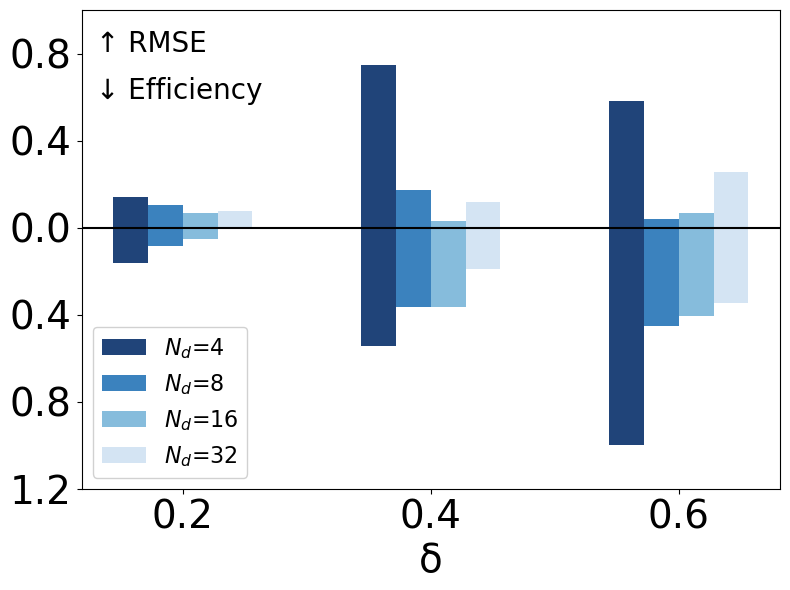

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 确保 figures 目录存在
os.makedirs('figures', exist_ok=True)

# 设置字体（如果需要）
plt.rcParams['font.family'] = 'sans-serif'

# 创建RMSE数据框
rmse_data = pd.DataFrame({
    'Length': [2, 2, 2, 2, 4, 4, 4, 4, 6, 6, 6, 6],
    'Nd': [4, 8, 16, 32, 4, 8, 16, 32, 4, 8, 16, 32],
    'Nstep': [45, 60, 70, 95, 20, 27, 27, 41, 12, 23, 25, 28],
    'RMSEp': [0.8245, 0.5420, 0.5153, 0.5357, 1.1346, 0.7056, 0.6702, 0.4935, 1.2800, 0.5582, 0.4373, 0.6071],
    'RMSEc': [0.1418, 0.1033, 0.0649, 0.0774, 0.7460, 0.1730, 0.0295, 0.1168, 0.5812, 0.0414, 0.0651, 0.2566]
})

# 创建Efficiency数据框（使用与RMSE相同的结构）
eff_data = pd.DataFrame({
    'Length': [2, 2, 2, 2, 4, 4, 4, 4, 6, 6, 6, 6],
    'Nd': [4, 8, 16, 32, 4, 8, 16, 32, 4, 8, 16, 32],
    'Nstep': [45, 60, 70, 95, 20, 27, 27, 41, 12, 23, 25, 28],
    'RMSEp': [0.8245, 0.5420, 0.5153, 0.5357, 1.1346, 0.7056, 0.6702, 0.4935, 1.2800, 0.5582, 0.4373, 0.6071],
    'RMSEc': [0.1418, 0.1033, 0.0649, 0.0774, 0.7460, 0.1730, 0.0295, 0.1168, 0.5812, 0.0414, 0.0651, 0.2566]
})

# Step 1: 计算原始 Efficiency = 1 / Nstep
eff_data['Efficiency_raw'] = 1.0 / eff_data['Nstep']

# Step 2: 全局 Min-Max 归一化到 [0, 1]
eff_min = eff_data['Efficiency_raw'].min()
eff_max = eff_data['Efficiency_raw'].max()
if eff_max == eff_min:
    # 防止除零（所有值相同）
    eff_data['Efficiency'] = 0.5
else:
    eff_data['Efficiency'] = (eff_data['Efficiency_raw'] - eff_min) / (eff_max - eff_min)

# 定义红色渐变色：Nd=4 最浅，Nd=32 最深（使用与RMSE相同的配色）
# red_colors = plt.cm.Reds(np.linspace(0.6, 0.1, 4))
red_colors = plt.cm.Blues(np.linspace(1, 0.2, 4))

# Nd 顺序固定为 [4, 8, 16, 32]
nd_order = [4, 8, 16, 32]
length_labels = ['0.2', '0.4', '0.6']
length_values = [2, 4, 6]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.14
n_groups = len(length_values)
index = np.arange(n_groups)

# 绘制RMSE柱状图（在0以上）
for i, nd in enumerate(nd_order):
    rmsec_values = []
    for length in length_values:
        row = rmse_data[(rmse_data['Length'] == length) & (rmse_data['Nd'] == nd)]
        if not row.empty:
            rmsec = row['RMSEc'].iloc[0]
        else:
            rmsec = 0  # 缺失数据用0表示
        rmsec_values.append(rmsec)
    
    ax.bar(index + i * bar_width, rmsec_values, bar_width,
           color=red_colors[i], label=f'$N_d$={nd}', edgecolor=None, linewidth=0.5, alpha = 0.9)

# 绘制Efficiency柱状图（在0以下，倒置显示）
for i, nd in enumerate(nd_order):
    efficiency_values = []
    for length in length_values:
        row = eff_data[(eff_data['Length'] == length) & (eff_data['Nd'] == nd)]
        if not row.empty:
            eff = row['Efficiency'].iloc[0]
        else:
            eff = 0  # 缺失数据用0表示
        efficiency_values.append(eff)
    
    # 将列表转换为numpy数组并取负值，实现倒置效果
    neg_efficiency_values = -np.array(efficiency_values)
    
    ax.bar(index + i * bar_width, neg_efficiency_values, bar_width,color=red_colors[i], edgecolor=None, linewidth=0.5, alpha=0.9)

# 设置横坐标
ax.set_xticks(index + bar_width * (len(nd_order) - 1) / 2)
ax.set_xticklabels(length_labels, fontsize=28)
ax.set_xlabel('δ', fontsize=28)

# # 设置纵坐标
# ax.set_ylabel('RMSE / Efficiency', fontsize=24)

# 设置Y轴范围
rmse_max = rmse_data['RMSEc'].max()
eff_max = eff_data['Efficiency'].max()
ymax_pos = rmse_max * 1.1
ymax_neg = -eff_max * 1.1

# 设置Y轴刻度 - 简化版本
# 正半轴刻度 (RMSE)
positive_ticks = np.arange(0, 1, 0.4)  # 0.0, 0.2, 0.4, 0.6, 0.8
# 负半轴刻度 (Efficiency)
negative_ticks = -np.arange(0, 1.3, 0.4)  # 0.0, -0.2, -0.4, -0.6, -0.8, -1.0

# 合并正负刻度
y_ticks = np.concatenate([negative_ticks, positive_ticks[1:]])  # 去掉一个0避免重复
y_tick_labels = []

# 创建刻度标签：正值为RMSE，负值为Efficiency（显示为正值）
for tick in y_ticks:
    if tick <= 0:
        # 负值显示为正值（因为柱子在下方，但数值应该是正的Efficiency）
        y_tick_labels.append(f'{abs(tick):.1f}')
    else:
        y_tick_labels.append(f'{tick:.1f}')

# 设置刻度
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=28)

# 添加0线
ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-')

# # 在纵轴两侧添加标签
# ax.text(-0.1, 0.5, 'RMSE', transform=ax.transAxes, 
#         fontsize=20, rotation=90, va='center', ha='center')
# ax.text(-0.1, -0.5, 'Efficiency', transform=ax.transAxes, 
#         fontsize=20, rotation=90, va='center', ha='center')

# 在0线附近添加文本标注
ax.text(0.02, 0.9, '↑ RMSE', transform=ax.transAxes, 
        fontsize=20, va='bottom', ha='left', color='black')
ax.text(0.02, 0.86, '↓ Efficiency', transform=ax.transAxes, 
        fontsize=20, va='top', ha='left', color='black')

# 图例 - 只显示一次（取前4个）
handles, labels = ax.get_legend_handles_labels()
if len(handles) > 4:
    handles = handles[:4]
    labels = labels[:4]

ax.legend(handles, labels, fontsize=16, loc='lower left', framealpha=0.9)

# 设置Y轴范围
ax.set_ylim(-1.2, 1)

# 调整布局并保存
plt.tight_layout()
plt.savefig('figures/combined_rmse_efficiency.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

# 压缩

In [3]:
import os
from PIL import Image

# 设置目录
figures_dir = "figures"

# 支持的 TIFF 扩展名（不区分大小写）
tiff_extensions = {'.tiff', '.tif'}

# 遍历目录中的所有文件
for filename in os.listdir(figures_dir):
    name, ext = os.path.splitext(filename)
    if ext.lower() in tiff_extensions:
        input_path = os.path.join(figures_dir, filename)
        
        # 统一输出为 .tif（小写）
        output_filename = name + ".tif"
        output_path = os.path.join(figures_dir, output_filename)

        try:
            # 打开图像
            with Image.open(input_path) as img:
                # 保留原始图像的所有信息（包括 mode、dpi 等）
                # 使用 LZW 无损压缩以减小文件体积，不损失精度
                save_kwargs = {
                    'format': 'TIFF',
                    'compression': 'tiff_lzw'
                }

                # 如果原图包含 DPI 信息，保留它
                if 'dpi' in img.info:
                    save_kwargs['dpi'] = img.info['dpi']

                # 如果是多页 TIFF（如动画或多帧），需要特殊处理（此处假设单页）
                # matplotlib 生成的通常是单页，所以直接保存即可
                img.save(output_path, **save_kwargs)
            
            print(f"✅ 已压缩并保存: {filename} -> {output_filename}")

        except Exception as e:
            print(f"❌ 处理 {filename} 时出错: {e}")

✅ 已压缩并保存: efficiency-errorbar.tif -> efficiency-errorbar.tif
✅ 已压缩并保存: efficiency-errorbar.tiff -> efficiency-errorbar.tif
✅ 已压缩并保存: rmsec-errorbar.tif -> rmsec-errorbar.tif
✅ 已压缩并保存: rmsec-errorbar.tiff -> rmsec-errorbar.tif
